## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import igraph as ig
from tqdm import tqdm
from collections import defaultdict
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight


## Load dataset

Full dataset consists 31 days of data, with about 3 days of data in val and test. We arbitrarily set block_size to 12 and window_size to 48.



In [2]:
df_train = pd.read_csv('../data/FEwithMerchants/FE_train_with_merchants.csv')
df_val = pd.read_csv('../data/FEwithMerchants/FE_validation_with_merchants.csv')
df_test = pd.read_csv('../data/FEwithMerchants/FE_test_with_merchants.csv')

# df_train = pd.read_csv('../data/FEwithoutMerchants/FE_train_without_merchants.csv')
# df_val = pd.read_csv('../data/FEwithoutMerchants/FE_validation_without_merchants.csv')
# df_test = pd.read_csv('../data/FEwithoutMerchants/FE_test_without_merchants.csv')

## Data Processing
- Convert to categorical columns to ensure XGBoost handles categorical features correctly
- Feature selection

In [3]:
print("Converting categorical columns ...")
categorical_cols = [
    'type', 'hourOfDay', 'dayOfWeek', 'transaction_sequence'
]

for col in categorical_cols:
    # Combine categories from both train, val and test, to avoid unseen categories during inference 
    combined_cats = pd.Series(
        pd.concat([df_train[col], df_val[col], df_test[col]], axis=0).dropna().unique()
    )
    categories = sorted(combined_cats.unique())

    df_train[col] = pd.Categorical(df_train[col], categories=categories)
    df_val[col]   = pd.Categorical(df_val[col], categories=categories)
    df_test[col]  = pd.Categorical(df_test[col], categories=categories)

Converting categorical columns ...


In [4]:
selected_features = [
    # transaction-level features
    'step', 'type', 'hourOfDay', 'day', 'amountLog', 
    'dayOfWeek', 
    # 'amount',         
                
    # account-level features
    'meanSent',
    'transaction_sequence',
    'totalSent', 'stdSent', 'numSent', 
    'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'maxAmountReceived', 
    'stdAmountReceived', 'avgAmountToDest', 'std_to_mean_ratio', 
    'pctForwarded24h',

    # transaction pattern features
    'transactionRecency', 'is_early_transaction',  'sequence_frequency', 'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
    'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

    # aggregated risk signals
    'typeHighValueFlag', 

    # centrality features
    "pagerank_diff", "receiver_indeg_amt",
    "sender_pr","receiver_pr", 
    "sender_outdeg_amt","sender_indeg_amt", "receiver_outdeg_amt",
    "sender_outdeg_cnt","sender_indeg_cnt", "receiver_outdeg_cnt","receiver_indeg_cnt",
    "outdeg_amt_diff","indeg_amt_diff", "outdeg_cnt_diff","indeg_cnt_diff",
]

In [5]:
print("Processing training set ...")
Xtrain, ytrain = df_train[selected_features].copy(), df_train["isFraud"].astype(int)

print("Processing validation set ...")
Xval, yval = df_val[selected_features].copy(), df_val["isFraud"].astype(int)

print("Processing test set ...")
Xtest, ytest = df_test[selected_features].copy(), df_test["isFraud"].astype(int)

print("Done!")

Processing training set ...
Processing validation set ...
Processing test set ...
Done!


## XGBoost Classifier
### Hyperparameter Tuning

To improve model performance, a **random search** over XGBoost hyperparameters was conducted using a predefined parameter grid.  
The search randomly samples 20 parameter combinations (`n_iter = 20`) from ranges covering model complexity, learning rate, regularization, and subsampling ratios.

Class imbalance between legitimate and fraudulent transactions was handled by:
- Setting **class weights** (`class_weights = {0: 1.0, 1: 2.0}`) to penalize the minority class more heavily.
- Computing **sample weights** for training and validation data to balance the contribution of each class.

For each sampled parameter set:
1. A model was trained on the training set with corresponding sample weights.
2. Performance was evaluated on the validation set using **AUC** (Area Under ROC Curve) and **PR-AUC** (Area Under Precision-Recall Curve).
3. Results were stored and sorted to identify the best-performing configuration.


In [6]:
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.005, 0.01, 0.05],
    'n_estimators': [100, 300, 600, 1000],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0.1, 0.2, 0.5, 0.8, 1],
    'reg_alpha': [0, 0.05, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 2, 3],
}
class_weights = {0: 1.0, 1: 2.0}

w_train = compute_sample_weight(class_weight=class_weights, y=ytrain)
w_val = compute_sample_weight(class_weight=class_weights, y=yval)

# n_iter = 3
n_iter = 20
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))
results = []

for params in tqdm(param_list, desc="Random Search Hyperparameter Tuning"):
    print("Training model with params:", params)
    model = XGBClassifier(
        **params,
        scale_pos_weight=(len(ytrain) - sum(ytrain)) / sum(ytrain),
        random_state=42,
        enable_categorical=True,
        eval_metric="aucpr",
        n_jobs=-1
    )

    # Evaluate on validation set 
    model.fit(Xtrain, 
            ytrain,
            sample_weight=w_train,
            eval_set=[(Xval, yval)],
            sample_weight_eval_set=[w_val], 
            verbose=False)

    yval_pred = model.predict_proba(Xval)[:, 1]
    auc = roc_auc_score(yval, yval_pred)
    pr_auc = average_precision_score(yval, yval_pred)

    results.append({
        **params,
        "auc": auc,
        "pr_auc": pr_auc,
    })

df_results = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
print(df_results.head(5))

Random Search Hyperparameter Tuning:   0%|          | 0/20 [00:00<?, ?it/s]

Training model with params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.005, 'gamma': 0.5, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:   5%|▌         | 1/20 [02:04<39:27, 124.61s/it]

Training model with params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 0.1, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  10%|█         | 2/20 [04:02<36:09, 120.55s/it]

Training model with params: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0.05, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.8, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  15%|█▌        | 3/20 [04:47<24:23, 86.06s/it] 

Training model with params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  20%|██        | 4/20 [05:22<17:32, 65.81s/it]

Training model with params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.005, 'gamma': 0.1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  25%|██▌       | 5/20 [05:56<13:37, 54.52s/it]

Training model with params: {'subsample': 0.8, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 0.5, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  30%|███       | 6/20 [06:36<11:33, 49.51s/it]

Training model with params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.5, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  35%|███▌      | 7/20 [07:17<10:06, 46.62s/it]

Training model with params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.5, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  40%|████      | 8/20 [11:59<24:19, 121.61s/it]

Training model with params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  45%|████▌     | 9/20 [14:05<22:35, 123.19s/it]

Training model with params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  50%|█████     | 10/20 [19:08<29:45, 178.55s/it]

Training model with params: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 1, 'colsample_bytree': 1.0}


Random Search Hyperparameter Tuning:  55%|█████▌    | 11/20 [21:58<26:22, 175.87s/it]

Training model with params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 0.05, 'n_estimators': 1000, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  60%|██████    | 12/20 [26:34<27:31, 206.46s/it]

Training model with params: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  65%|██████▌   | 13/20 [30:34<25:14, 216.43s/it]

Training model with params: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 0.5, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  70%|███████   | 14/20 [31:19<16:28, 164.83s/it]

Training model with params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.05, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  75%|███████▌  | 15/20 [36:36<17:33, 210.68s/it]

Training model with params: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.8, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  80%|████████  | 16/20 [37:18<10:39, 159.92s/it]

Training model with params: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.8, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  85%|████████▌ | 17/20 [38:05<06:18, 126.01s/it]

Training model with params: {'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.05, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.005, 'gamma': 0.1, 'colsample_bytree': 0.6}


Random Search Hyperparameter Tuning:  90%|█████████ | 18/20 [44:39<06:53, 206.52s/it]

Training model with params: {'subsample': 1.0, 'reg_lambda': 3, 'reg_alpha': 0.05, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning:  95%|█████████▌| 19/20 [46:29<02:57, 177.36s/it]

Training model with params: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.005, 'gamma': 0.8, 'colsample_bytree': 0.8}


Random Search Hyperparameter Tuning: 100%|██████████| 20/20 [48:43<00:00, 146.19s/it]

    subsample  reg_lambda  reg_alpha  n_estimators  min_child_weight  \
18        1.0         3.0       0.05           300                 3   
10        1.0         3.0       0.00           600                 1   
15        1.0         2.0       0.10           100                 1   
7         0.8         1.0       0.50          1000                 5   
11        1.0         1.0       0.05          1000                10   

    max_depth  learning_rate  gamma  colsample_bytree       auc    pr_auc  
18          5           0.05    0.5               0.8  0.959660  0.364754  
10          3           0.05    1.0               1.0  0.961494  0.348043  
15          5           0.05    0.8               0.8  0.961913  0.337229  
7           3           0.05    0.1               1.0  0.959395  0.334209  
11          3           0.05    0.1               0.8  0.958258  0.303297  


### Choosing the Best Model
The model with the **highest PR-AUC score** was identified as the best model, since PR-AUC is more informative for imbalanced classification problems (e.g., fraud detection). 


In [7]:
# Best model from Randomized Search
best_model_info = df_results.iloc[0]
best_model_info = best_model_info.to_dict()
best_model_info = {k: int(v) if isinstance(v, float) and v.is_integer() else v
               for k, v in best_model_info.items()}

print("=== Best model hyperparameters from Random Search Hyperparameter Tuning ===")
for k, v in best_model_info.items():
    print(f"{k:<20}: {v}")

# remove metrics from best_model_info to get only parameters
best_model_info.pop("auc", None)
best_model_info.pop("pr_auc", None)
best_params = best_model_info

=== Best model hyperparameters from Random Search Hyperparameter Tuning ===
subsample           : 1
reg_lambda          : 3
reg_alpha           : 0.05
n_estimators        : 300
min_child_weight    : 3
max_depth           : 5
learning_rate       : 0.05
gamma               : 0.5
colsample_bytree    : 0.8
auc                 : 0.9596604018612609
pr_auc              : 0.3647538892263301


## Final Model Training
After identifying the optimal hyperparameters from the random search, a final XGBoost model was trained using the combined training and validation datasets.  
Merging these datasets (`Xtrain_full`, `ytrain_full`) allows the model to learn from all available labeled data, improving generalization before final testing.

To maintain balanced learning despite class imbalance, sample weights were recalculated using the same class weight configuration as before.


In [8]:
Xtrain_full = pd.concat([Xtrain, Xval])
ytrain_full = pd.concat([ytrain, yval])
w_full = compute_sample_weight(class_weight=class_weights, y=ytrain_full)

# Final model using tuned parameters
best_xgb = XGBClassifier(
    **best_params,          
    random_state=42,
    enable_categorical=True,
    n_jobs=-1,
    eval_metric="aucpr"
)

best_xgb.fit(Xtrain_full, ytrain_full, sample_weight=w_full)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'aucpr'


## Feature Importance

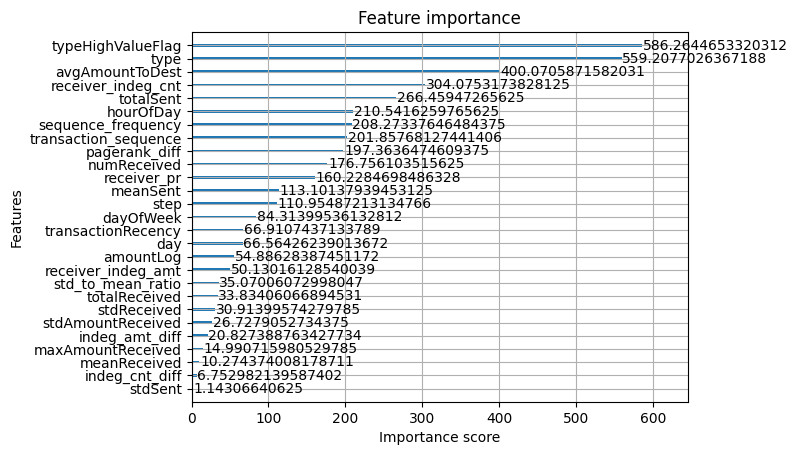

In [9]:
xgb.plot_importance(best_xgb, importance_type='gain')
plt.show()

Train ROC-AUC: 0.9849133680599591
Train PR-AUC : 0.6467420434314975

Test ROC-AUC: 0.9648826980780696
Test PR-AUC : 0.30819123957195527


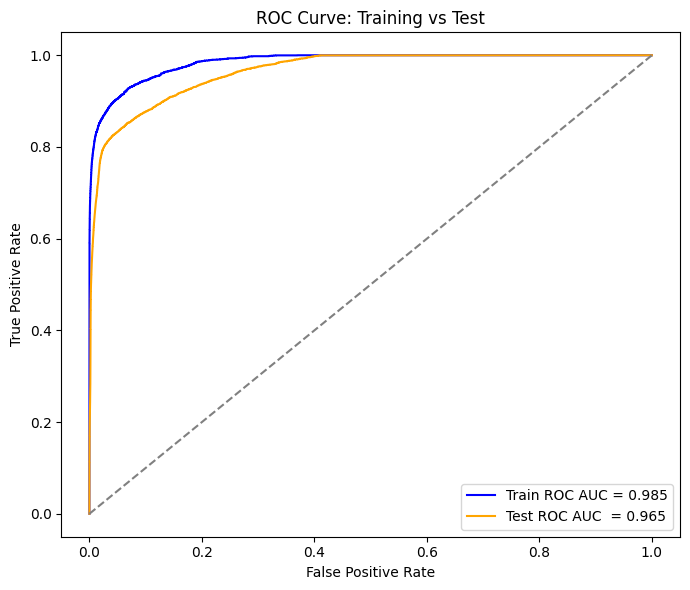

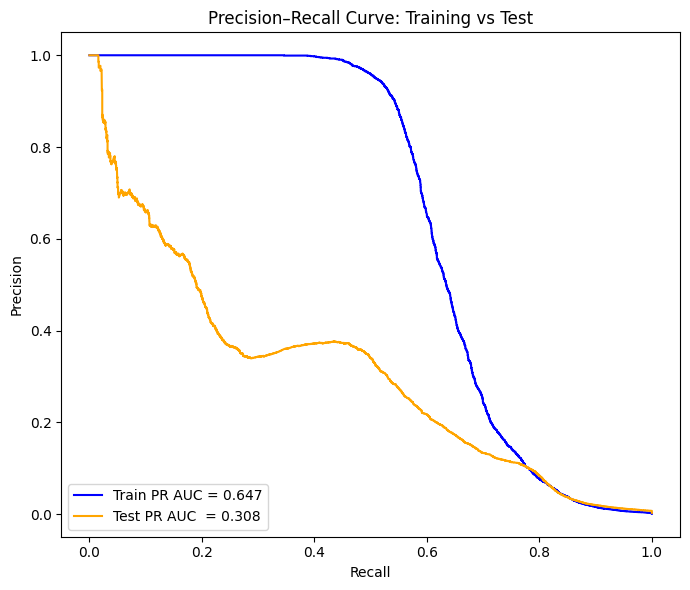

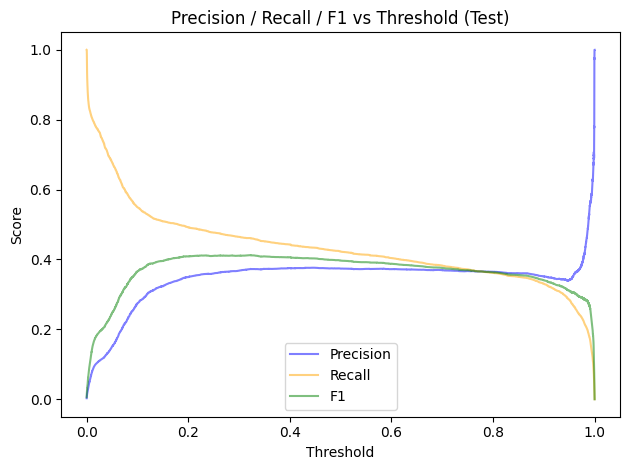

In [10]:
ytrain_proba = best_xgb.predict_proba(Xtrain_full)[:, 1]
ytest_proba = best_xgb.predict_proba(Xtest)[:, 1]
print("Train ROC-AUC:", roc_auc_score(ytrain_full, ytrain_proba))
print("Train PR-AUC :", average_precision_score(ytrain_full, ytrain_proba))
print("\nTest ROC-AUC:", roc_auc_score(ytest, ytest_proba))
print("Test PR-AUC :", average_precision_score(ytest, ytest_proba))

ytrain_true = ytrain_full.astype(int)
ytest_true = ytest.astype(int)

# --- ROC Curves ---
fpr_train, tpr_train, _ = roc_curve(ytrain_true, ytrain_proba)
roc_auc_train = roc_auc_score(ytrain_true, ytrain_proba)

fpr_test, tpr_test, thr_roc_test = roc_curve(ytest_true, ytest_proba)
roc_auc_test = roc_auc_score(ytest_true, ytest_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr_train, tpr_train, label=f"Train ROC AUC = {roc_auc_train:.3f}", color="blue")
plt.plot(fpr_test,  tpr_test,  label=f"Test ROC AUC  = {roc_auc_test:.3f}", color="orange")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Training vs Test")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# --- Precision–Recall Curves ---
prec_train, rec_train, thr_pr_train = precision_recall_curve(ytrain_true, ytrain_proba)
prec_test,  rec_test,  thr_pr_test  = precision_recall_curve(ytest_true,  ytest_proba)
ap_train = average_precision_score(ytrain_true, ytrain_proba)
ap_test  = average_precision_score(ytest_true,  ytest_proba)

plt.figure(figsize=(7,6))
plt.plot(rec_train, prec_train, label=f"Train PR AUC = {ap_train:.3f}", color="blue")
plt.plot(rec_test,  prec_test,  label=f"Test PR AUC  = {ap_test:.3f}", color="orange")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve: Training vs Test")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

# --- Precision / Recall / F1 vs Threshold ---
thr_test  = np.r_[0.0, thr_pr_test]
f1_test  = 2 * (prec_test  * rec_test)  / np.clip(prec_test  + rec_test,  1e-12, None)

plt.plot(thr_test, prec_test, label="Precision", color="blue", alpha=0.5)
plt.plot(thr_test, rec_test,  label="Recall", color="orange", alpha=0.5)
plt.plot(thr_test, f1_test,   label="F1", color="green", alpha=0.5)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold (Test)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
from sklearn.metrics import classification_report

# Choose threshold based on business requirements/ PR curve
# 1. constant
# best_thr = 0.371

# 2. max F1 (ie high recall, high precision)
best_thr = thr_test[np.argmax(f1_test)]

# 3. highest precision with specified recall
# best_thr = thr[np.where(rec >= 0.8)[0][-1]]

print(f"Threshold: {best_thr:.4f}")

ytest_pred = (ytest_proba >= best_thr).astype(int)
print("Test Classification Report:")
print(classification_report(ytest, ytest_pred))


Threshold: 0.3230
Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1459068
           1       0.37      0.46      0.41      4336

    accuracy                           1.00   1463404
   macro avg       0.69      0.73      0.71   1463404
weighted avg       1.00      1.00      1.00   1463404

